# Look at RACMO climate for the ERA5 reanalysis data

1. How stable is the climate for two spinup periods?
2. What is the average change in precipitation, surface temperature, and snowmelt over the whole period?

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from scipy import stats


In [6]:
#set paths
variables     = ["ff10m","precip_liq","evap","sndiv","snowfall","snowmelt","tskin"]
file_variables = ["ff10m","precip","evap","sndiv","snowfall","snowmelt","tskin"]
RACMO_ts_dir = "/home/nld4814/scratch/FGRN055_era055/input/timeseries"
RACMO_avg_dir = "/home/nld4814/scratch/FGRN055_era055/input/averages"
MONTHLY_DIR = "/home/nld4814/scratch/FGRN055_era055/input/monthly"
MASK_FILE   = "/home/nld4814/perm/code/IMAU-FDM/reference/FGRN055/FGRN055_Masks.nc"


In [7]:

# Check that monthly files exist
missing = [v for v in file_variables
           if not os.path.exists(f"{MONTHLY_DIR}/{v}_FGRN055_era055_1939-2023_monthly.nc")]
if missing:
    raise FileNotFoundError(
        f"Monthly files not found for: {missing}\n"
        f"Run:  sbatch 'RACMO climate/submit_racmo_monthly.sh'  to create them."
    )

# Load ice mask
ds_mask    = xr.open_dataset(MASK_FILE)
icemask_np = ds_mask["Icemask_GR"].squeeze(drop=True).values.astype(bool)
icemask_da = xr.DataArray(icemask_np, dims=["rlat", "rlon"])
ds_mask.close()

def load_spatial_mean(var):
    f  = f"{MONTHLY_DIR}/{var}_FGRN055_era055_1939-2023_monthly.nc"
    ds = xr.open_dataset(f)
    masked = ds[var].where(icemask_da)
    result = masked.mean(dim=["rlat", "rlon"]).load()
    ds.close()
    return result

# Load and spatial-average one variable at a time
data = {}
for var in file_variables:
    data[var] = load_spatial_mean(var)
    print(f"  {var} loaded")

# Derive liquid precipitation from gridded files before discarding grids
f_precip   = f"{MONTHLY_DIR}/precip_FGRN055_era055_1939-2023_monthly.nc"
f_snowfall = f"{MONTHLY_DIR}/snowfall_FGRN055_era055_1939-2023_monthly.nc"
ds_p = xr.open_dataset(f_precip)
ds_s = xr.open_dataset(f_snowfall)
precip_liq_grid = (ds_p["precip"] - ds_s["snowfall"]).clip(min=0)
data["precip_liq"] = precip_liq_grid.where(icemask_da).mean(dim=["rlat", "rlon"]).load()
ds_p.close()
ds_s.close()
print(f"  precip_liq: loaded")

print("All variables loaded.")


  ff10m loaded
  precip loaded
  evap loaded
  sndiv loaded
  snowfall loaded
  snowmelt loaded
  tskin loaded
  precip_liq: loaded
All variables loaded.


In [10]:
# define plotting function 


def plot_racmo_climate(data, start_date, end_date, suptitle):

    var_meta = {
        "ff10m":      ("Wind speed at 10 m",      "m s⁻¹"),
        "precip_liq": ("Liquid precipitation",     "kg m⁻² a⁻¹"),
        "evap":       ("Evaporation",              "kg m⁻² a⁻¹"),
        "sndiv":      ("Snow drifting",            "kg m⁻² a⁻¹"),
        "snowfall":   ("Snowfall",                 "kg m⁻² a⁻¹"),
        "snowmelt":   ("Snowmelt",                 "kg m⁻² a⁻¹"),
        "tskin":      ("Skin temperature",         "K"),
    }

    spy = 365.25*24*3600
    ncols = 4
    nrows = (len(variables) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True)

    sliced_data = {var: da.sel(time=slice(start_date, end_date)) for var, da in data.items()}

    for i, var in enumerate(variables):
        ax = axes.flat[i]
        t_yr = sliced_data[var].time.dt.year.values + (sliced_data[var].time.dt.month.values - 1) / 12

        if var in ("tskin", "ff10m"):
            vals      = sliced_data[var].values
            annual    = sliced_data[var].resample(time="YE").mean()
            annual_std = sliced_data[var].resample(time="YE").std()
            full_vals = data[var].values
        else:
            vals      = sliced_data[var].values * spy
            annual    = sliced_data[var].resample(time="YE").mean() * spy
            annual_std = sliced_data[var].resample(time="YE").std() * spy
            full_vals = data[var].values * spy

        ax.plot(t_yr, vals, lw=0.8, color="steelblue", alpha=0.7)

        # Annual mean ± 1 std
        t_ann = annual.time.dt.year.values + 0.5
        ann_vals = annual.values
        ann_std  = annual_std.values
        ax.plot(t_ann, ann_vals, lw=2, color="navy", label="annual mean ± 1σ")
        ax.fill_between(t_ann, ann_vals - ann_std, ann_vals + ann_std,
                        color="navy", alpha=0.15)

        # Linear trend with 95% confidence interval
        result = stats.linregress(t_yr, vals.astype(float))
        slope, intercept, stderr = result.slope, result.intercept, result.stderr
        fit_line = slope * t_yr + intercept

        n = len(t_yr)
        t_crit = stats.t.ppf(0.975, df=n - 2)
        t_mean = t_yr.mean()
        se_line = stderr * np.sqrt(1/n + (t_yr - t_mean)**2 / np.sum((t_yr - t_mean)**2))
        ci = t_crit * se_line

        total_change = fit_line[-1] - fit_line[0]
        total_uncert = stderr * t_crit * (t_yr[-1] - t_yr[0])
        ax.plot(t_yr, fit_line, "r--", lw=1.2,
                label=f"trend: {slope * 10:.3g} ± {stderr * t_crit * 10:.2g} / decade\n"
                      f"total: {total_change:+.3g} ± {total_uncert:.2g}")
        ax.fill_between(t_yr, fit_line - ci, fit_line + ci, color="red", alpha=0.15)

        # Fix y-axis to full-timeseries range
        ax.set_ylim(np.nanmin(full_vals), np.nanmax(full_vals))

        label, unit = var_meta[var]
        ax.set_title(label, fontsize=11)
        ax.set_ylabel(unit, fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for j in range(len(variables), len(axes.flat)):
        axes.flat[j].set_visible(False)

    # Label x-axis on each visible bottom-row panel
    for i in range((nrows - 1) * ncols, len(variables)):
        axes.flat[i].set_xlabel("Year", fontsize=10)

    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()


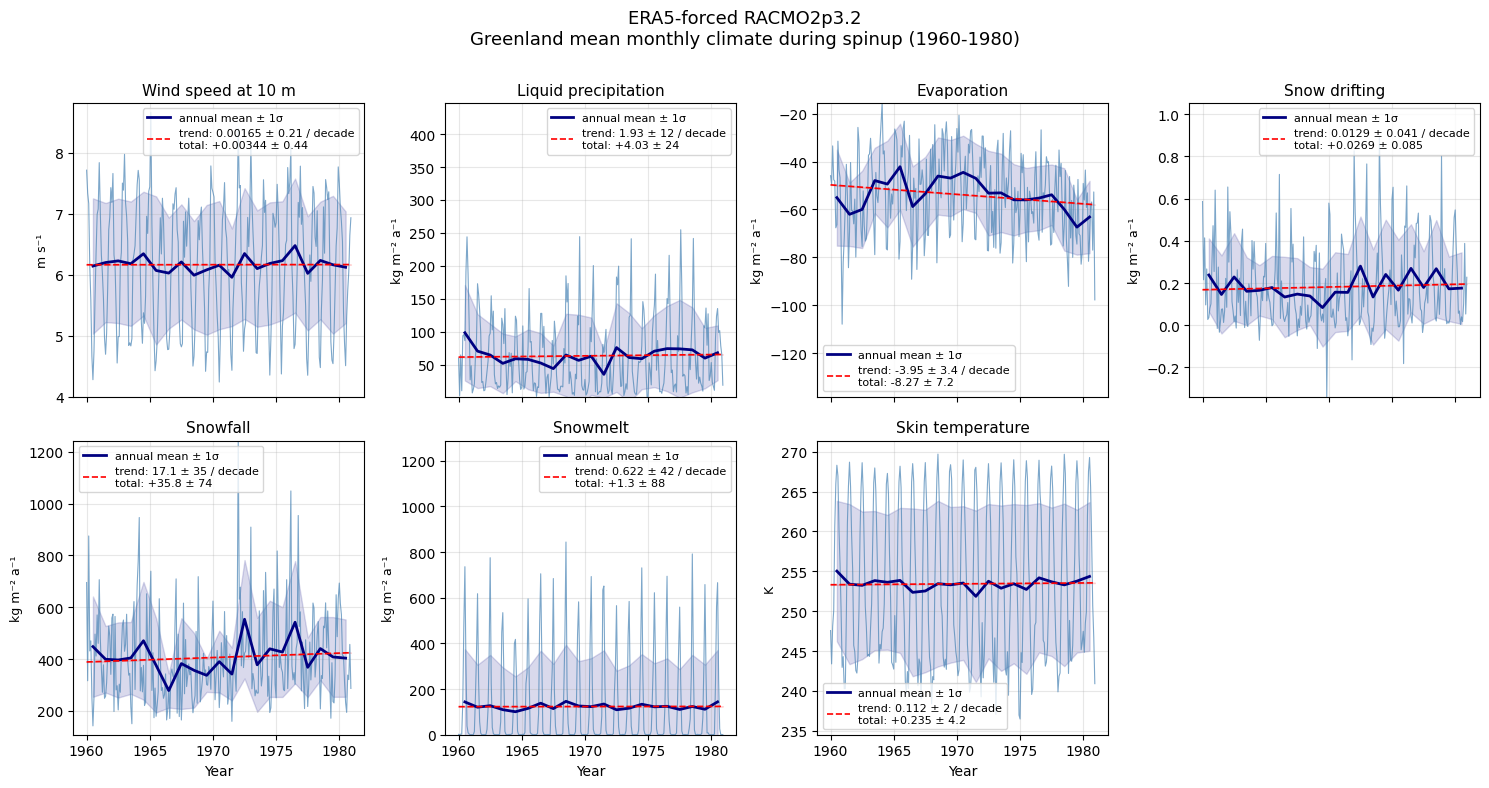

In [11]:
start_date = "1960"
end_date = "1980"
plot_racmo_climate(data, start_date, end_date, suptitle = f"ERA5-forced RACMO2p3.2\nGreenland mean monthly climate during spinup ({pd.to_datetime(start_date).year}-{pd.to_datetime(end_date).year})\n")

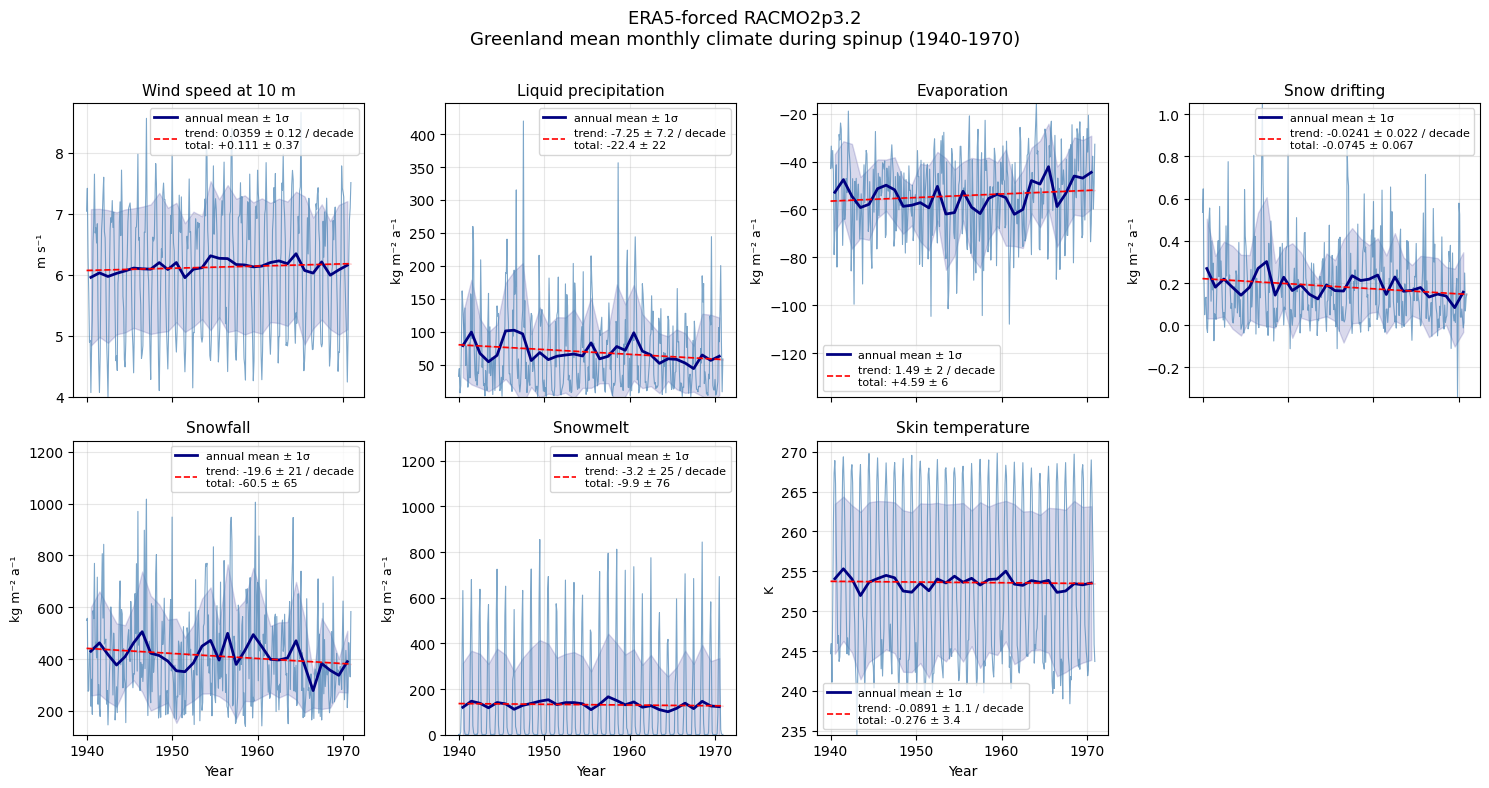

In [12]:
start_date = "1940"
end_date = "1970"
plot_racmo_climate(data, start_date, end_date, suptitle = f"ERA5-forced RACMO2p3.2\nGreenland mean monthly climate during spinup ({pd.to_datetime(start_date).year}-{pd.to_datetime(end_date).year})\n")

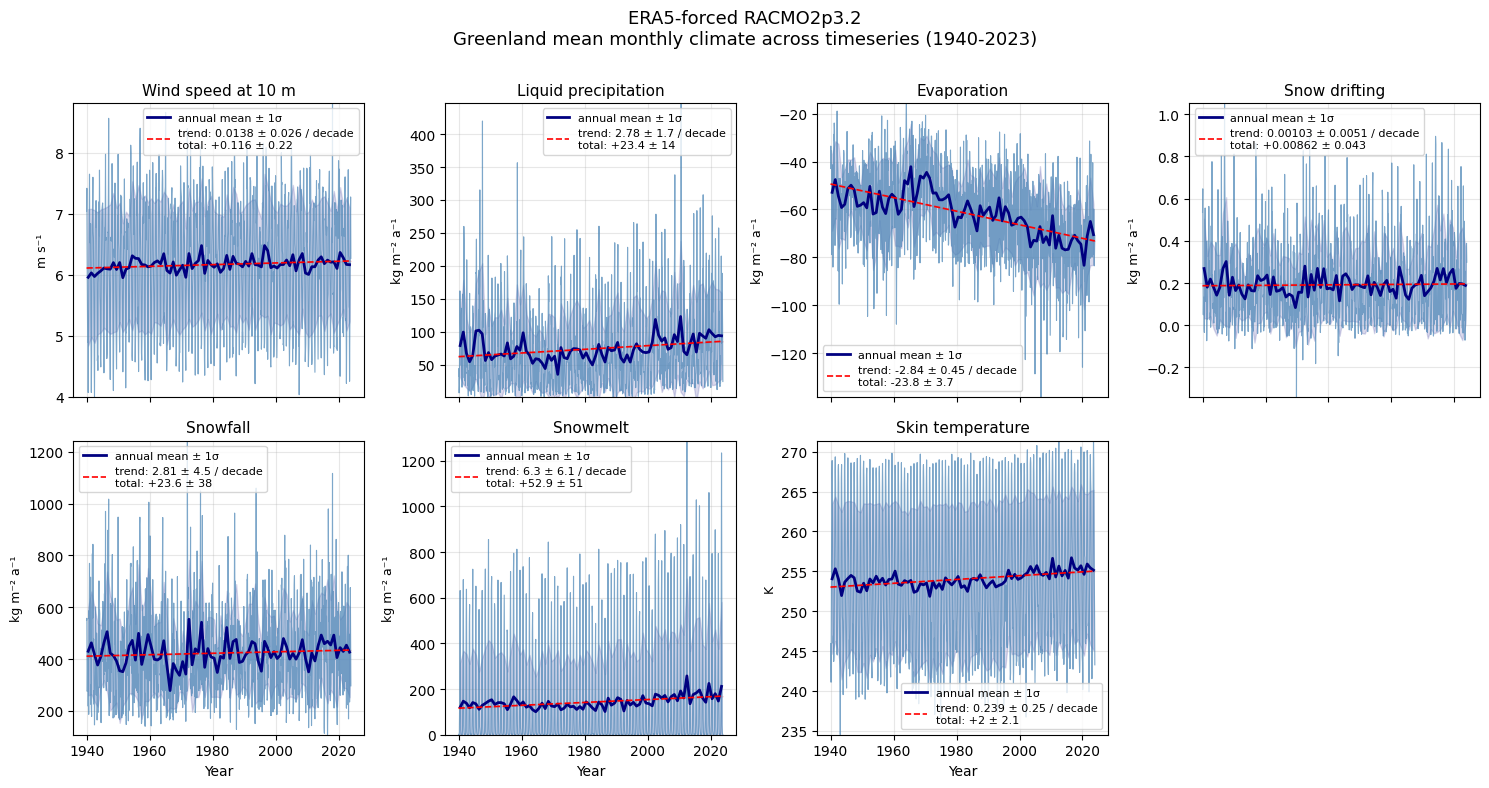

In [13]:
start_date = "1940"
end_date = "2023"
plot_racmo_climate(data, start_date, end_date, suptitle = f"ERA5-forced RACMO2p3.2\nGreenland mean monthly climate across timeseries ({pd.to_datetime(start_date).year}-{pd.to_datetime(end_date).year})\n")


## Changepoint analysis: when does skin temperature begin to rise?

Two complementary tests on annual-mean tskin (1940–2023):

1. **Pettitt test** (non-parametric) — detects a single shift in the *mean*. Standard in climatology; no distributional assumption needed. Reports the most likely changepoint year and an approximate p-value.
2. **Segmented (piecewise-linear) regression** — fits two linear segments joined at a breakpoint, finding the year that minimises total RSS. Directly answers "when does the upward *trend* begin?". The RSS-profile plot shows how sharp / well-constrained the estimate is.


In [ ]:
def pettitt_test(x):
    """
    Pettitt (1979) non-parametric changepoint test.
    Returns (changepoint_index, U_statistic, approx_p_value).
    p-value approximation from Pettitt (1979), eq. 11.
    """
    n = len(x)
    U_t = np.zeros(n - 1)
    for t in range(1, n):
        for i in range(t):
            for j in range(t, n):
                if x[j] > x[i]:
                    U_t[t - 1] += 1
                elif x[j] < x[i]:
                    U_t[t - 1] -= 1
    K = np.max(np.abs(U_t))
    t_star = np.argmax(np.abs(U_t))   # 0-indexed among 1..n-1
    # Approximate p-value (Pettitt 1979, eq. 11)
    p = 2 * np.exp(-6 * K**2 / (n**3 + n**2))
    return t_star + 1, K, min(p, 1.0)   # +1 → index into original array


def segmented_regression_rss(years, values, min_seg=10):
    """
    Brute-force search for the breakpoint year that minimises total RSS
    of a piecewise-linear (two-segment) fit.
    min_seg: minimum number of points required in each segment.
    Returns (best_year, rss_profile) where rss_profile is an array over candidate years.
    """
    n = len(years)
    candidates = years[min_seg: n - min_seg]
    rss_all = np.full(len(candidates), np.nan)

    for k, bp in enumerate(candidates):
        mask1 = years <= bp
        mask2 = years >  bp
        r1 = stats.linregress(years[mask1], values[mask1])
        r2 = stats.linregress(years[mask2], values[mask2])
        res1 = values[mask1] - (r1.slope * years[mask1] + r1.intercept)
        res2 = values[mask2] - (r2.slope * years[mask2] + r2.intercept)
        rss_all[k] = np.sum(res1**2) + np.sum(res2**2)

    best_idx = np.nanargmin(rss_all)
    return int(candidates[best_idx]), candidates, rss_all


# ── Build annual-mean tskin (1940–2023) ─────────────────────────────────────
tskin_annual = data["tskin"].sel(time=slice("1940", "2023")).resample(time="YE").mean()
years  = tskin_annual.time.dt.year.values
values = tskin_annual.values.astype(float)

# ── 1. Pettitt test ──────────────────────────────────────────────────────────
cp_idx, K_stat, p_val = pettitt_test(values)
cp_year_pettitt = years[cp_idx]
print(f"Pettitt test:  changepoint at {cp_year_pettitt}  (K={K_stat:.0f}, p≈{p_val:.4f})")

# ── 2. Segmented regression ──────────────────────────────────────────────────
bp_year, cand_years, rss_profile = segmented_regression_rss(years, values, min_seg=10)
print(f"Segmented regression:  best breakpoint at {bp_year}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: time series with both changepoints marked
ax = axes[0]
ax.plot(years, values, "o-", ms=4, lw=1.2, color="steelblue", label="annual mean tskin")
ax.axvline(cp_year_pettitt, color="darkorange", lw=2, ls="--",
           label=f"Pettitt cp: {cp_year_pettitt} (p≈{p_val:.3f})")
ax.axvline(bp_year, color="crimson", lw=2, ls=":",
           label=f"Seg. regression bp: {bp_year}")

# Overlay the two-segment fit for the segmented regression breakpoint
m1 = years <= bp_year;  m2 = years > bp_year
r1 = stats.linregress(years[m1], values[m1])
r2 = stats.linregress(years[m2], values[m2])
ax.plot(years[m1], r1.slope * years[m1] + r1.intercept, "r-", lw=1.5, alpha=0.7)
ax.plot(years[m2], r2.slope * years[m2] + r2.intercept, "r-", lw=1.5, alpha=0.7,
        label=f"seg. slopes: {r1.slope*10:.3f} / {r2.slope*10:.3f} K decade⁻¹")
ax.set_xlabel("Year"); ax.set_ylabel("Tskin (K)")
ax.set_title("Annual mean skin temperature with changepoints")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Right: RSS profile
ax2 = axes[1]
ax2.plot(cand_years, rss_profile, color="steelblue")
ax2.axvline(bp_year, color="crimson", lw=2, ls=":", label=f"minimum RSS at {bp_year}")
ax2.set_xlabel("Candidate breakpoint year")
ax2.set_ylabel("Total RSS (K²)")
ax2.set_title("Segmented regression RSS profile")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle("Tskin changepoint analysis (1940–2023)", fontsize=12)
plt.tight_layout()
plt.show()
